<a href="https://colab.research.google.com/github/EstebanUMBJ/Google-Colab-Projects/blob/main/Habit_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANÁLISIS DE HÁBITOS PERSONALES


##1. Importación de librerías

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

##2. Configuración de los gráficos

In [ ]:

plt.rcParams['figure.figsize'] = (12, 5)   # ancho x alto en pulgadas
plt.rcParams['axes.spines.top']   = False  # quita el borde superior
plt.rcParams['axes.spines.right'] = False  # quita el borde derecho
sns.set_palette("husl")                    # paleta de colores accesible

##3. Carga de datos

In [ ]:
np.random.seed(42)  # semilla para que los datos aleatorios sean reproducibles
n = 90              # número de días a simular

fecha_inicio = pd.Timestamp("2024-01-01")

df = pd.DataFrame({
    "Date":
        pd.date_range(start=fecha_inicio, periods=n, freq="D"),

    "Sleep_Hours":
        # normal(media, desviación) → simula horas de sueño reales
        np.clip(np.random.normal(7.0, 1.0, n), 3, 10).round(1),

    "Workout_Duration_Min":
        # Muchos días sin ejercicio (0), otros con entre 20 y 90 min
        np.where(
            np.random.rand(n) > 0.35,
            np.random.randint(20, 90, n),
            0
        ).astype(float),

    "Journaling (Y/N)":
        # 60% de los días se hace journaling
        np.random.choice(["Y", "N"], n, p=[0.6, 0.4]),

    "Reading_Min":
        np.clip(np.random.normal(30, 15, n), 0, 120).round(0),

    "Screen_Time_Hours":
        np.clip(np.random.normal(4.5, 1.5, n), 1, 12).round(1),

    "Daily_Expense (RM)":
        np.clip(np.random.normal(50, 20, n), 5, 150).round(2),

    "Mood_Score (1-10)":
        # El humor correlaciona positivamente con sueño y ejercicio
        # np.clip asegura que el valor quede entre 1 y 10
        np.clip(
            (
                np.random.normal(6, 1.2, n)
                + 0.3 * (np.random.normal(7, 1, n) - 7)   # efecto sueño
                + 0.2 * (np.random.normal(30, 20, n) / 60) # efecto ejercicio
            ),
            1, 10
        ).round(1)
})

print(f"✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"   Período: {df['Date'].min().date()} → {df['Date'].max().date()}")

✅ Dataset cargado: 90 filas × 8 columnas
   Período: 2024-01-01 → 2024-03-30


##4. Exploración inicial

In [ ]:
print("=" * 55)
print("1. Primeras 5 filas del dataset")
print("=" * 55)
# head(n) muestra las n primeras filas. Es como abrir el archivo en Excel
# y mirar las primeras líneas para saber qué hay dentro.
print(df.head())

print("\n" + "=" * 55)
print("2. Estructura del dataset")
print("=" * 55)
# info() nos da:
#   - Número total de filas
#   - Nombre de cada columna
#   - Cuántos valores NO son nulos (non-null count)
#   - El tipo de dato de cada columna (int, float, object, datetime)
# Es imprescindible para detectar columnas que deberían ser numéricas
# pero Python interpretó como texto (object).
df.info()

print("\n" + "=" * 55)
print("3. Estadísticas descriptivas")
print("=" * 55)
# describe() calcula automáticamente para cada columna NUMÉRICA:
#   count → cuántos valores hay (útil para detectar vacíos)
#   mean  → la media (promedio)
#   std   → desviación estándar (cuánto varían los datos)
#   min / max → valores extremos
#   25%, 50%, 75% → los cuartiles (cómo se distribuyen los datos)
print(df.describe().round(2))

print("\n" + "=" * 55)
print("4. Valores nulos por columna")
print("=" * 55)
# isnull() devuelve True/False para cada celda
# .sum() cuenta cuántos True (= nulos) hay por columna
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ Sin valores nulos")

1. Primeras 5 filas del dataset
        Date  Sleep_Hours  Workout_Duration_Min Journaling (Y/N)  Reading_Min  \
0 2024-01-01          7.5                  37.0                Y         34.0   
1 2024-01-02          6.9                  85.0                Y         21.0   
2 2024-01-03          7.6                  73.0                Y         27.0   
3 2024-01-04          8.5                  54.0                Y         23.0   
4 2024-01-05          6.8                   0.0                Y         21.0   

   Screen_Time_Hours  Daily_Expense (RM)  Mood_Score (1-10)  
0                7.8               39.39                6.6  
1                3.3               38.48                5.9  
2                3.2               44.50                6.9  
3                3.6                5.00                8.8  
4                1.3               19.70                7.0  

2. Estructura del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns

##5. Limpieza y preparación de los datos

In [ ]:
# Convertir la columna Date a tipo datetime.
# Cuando pandas lee un CSV, la columna de fechas llega como texto (string).
# Para poder calcular días entre fechas, ordenar cronológicamente y
# hacer gráficos con eje de tiempo, necesitamos convertirla a datetime.
if df["Date"].dtype == "object":
    df["Date"] = pd.to_datetime(df["Date"])
    print("✅ Columna 'Date' convertida a datetime")
else:
    print("✅ Columna 'Date' ya es datetime")

# Establecer Date como índice
# El índice es la "etiqueta" de cada fila. Al usar la fecha como índice,
# podemos buscar datos por fecha: df.loc["2024-03"]
df = df.set_index("Date")

# Renombrar columnas (nombres más cortos y manejables)
# Los nombres originales tienen espacios y caracteres especiales, lo cual
# puede causar errores. Es buena práctica usar nombres simples y en minúsculas.
df = df.rename(columns={
    "Sleep_Hours":           "sleep_h",
    "Workout_Duration_Min":  "workout_min",
    "Journaling (Y/N)":      "journaling",
    "Reading_Min":           "reading_min",
    "Screen_Time_Hours":     "screen_h",
    "Daily_Expense (RM)":    "expense_rm",
    "Mood_Score (1-10)":     "mood"
})

# Convertir columna de journaling a 0/1 (codificación binaria)
# Los algoritmos de análisis trabajan con números, no con texto "Y"/"N".
# Mapeamos: Y → 1, N → 0
df["journaling"] = df["journaling"].map({"Y": 1, "N": 0})

# Crear columna derivada: día de la semana
# Una "feature engineering" básica: extraer el día de la semana del índice.
# Útil para detectar patrones (¿dormimos peor los domingos? ¿ejercitamos
# más los lunes?). dayofweek: 0=lunes, 6=domingo
df["weekday"] = df.index.dayofweek
DIAS = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

# Tratar valores nulos (si existen)
# fillna(method='ffill') = forward fill: rellena con el último valor conocido.
# Alternativa: df.fillna(df.mean()) rellena con la media de cada columna.
# Para este dataset usamos la media, que es más conservadora.
cols_numericas = df.select_dtypes(include="number").columns
antes = df[cols_numericas].isnull().sum().sum()
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].mean())
despues = df[cols_numericas].isnull().sum().sum()
print(f"✅ Nulos tratados: {antes} → {despues}")

print(f"\n✅ Dataset limpio: {df.shape[0]} filas × {df.shape[1]} columnas")
print(df.dtypes)

✅ Columna 'Date' ya es datetime
✅ Nulos tratados: 0 → 0

✅ Dataset limpio: 90 filas × 8 columnas
sleep_h        float64
workout_min    float64
journaling       int64
reading_min    float64
screen_h       float64
expense_rm     float64
mood           float64
weekday          int32
dtype: object


##6. Análisis estadístico

In [ ]:
print("=" * 55)
print("Resumen estadístico por hábito")
print("=" * 55)

metricas = {
    "Sueño (h)":         df["sleep_h"],
    "Ejercicio (min)":   df["workout_min"],
    "Lectura (min)":     df["reading_min"],
    "Pantalla (h)":      df["screen_h"],
    "Gasto (RM)":        df["expense_rm"],
    "Humor (1-10)":      df["mood"],
}

for nombre, serie in metricas.items():
    print(f"\n  {nombre}")
    print(f"    Media:    {serie.mean():.2f}")
    print(f"    Mediana:  {serie.median():.2f}")
    print(f"    Mín/Máx:  {serie.min():.1f} / {serie.max():.1f}")
    print(f"    Desv.Std: {serie.std():.2f}")

# Porcentaje de días con journaling
pct_journaling = df["journaling"].mean() * 100
print(f"\n  Journaling: {pct_journaling:.1f} % de los días")

# Días con y sin ejercicio
dias_ejercicio = (df["workout_min"] > 0).sum()
print(f"  Días con ejercicio: {dias_ejercicio} de {len(df)} ({dias_ejercicio/len(df)*100:.0f}%)")

# Promedios por día de la semana
print("\n" + "=" * 55)
print("Humor promedio por días de la semana")
print("=" * 55)
humor_semana = df.groupby("weekday")["mood"].mean()
for i, v in humor_semana.items():
    barra = "█" * int(v * 2)
    print(f"  {DIAS[i]:3s}  {barra:20s}  {v:.2f}")

Resumen estadístico por hábito

  Sueño (h)
    Media:    6.90
    Mediana:  6.90
    Mín/Máx:  4.4 / 8.9
    Desv.Std: 0.94

  Ejercicio (min)
    Media:    32.71
    Mediana:  35.00
    Mín/Máx:  0.0 / 88.0
    Desv.Std: 31.06

  Lectura (min)
    Media:    31.88
    Mediana:  31.00
    Mín/Máx:  8.0 / 62.0
    Desv.Std: 11.22

  Pantalla (h)
    Media:    4.45
    Mediana:  4.40
    Mín/Máx:  1.3 / 7.8
    Desv.Std: 1.58

  Gasto (RM)
    Media:    46.84
    Mediana:  45.58
    Mín/Máx:  5.0 / 111.6
    Desv.Std: 19.75

  Humor (1-10)
    Media:    6.13
    Mediana:  6.10
    Mín/Máx:  3.0 / 8.8
    Desv.Std: 1.30

  Journaling: 67.8 % de los días
  Días con ejercicio: 53 de 90 (59%)

Humor promedio por días de la semana
  Lun  ████████████          6.22
  Mar  ███████████           5.94
  Mié  ████████████          6.24
  Jue  ████████████          6.36
  Vie  ███████████           5.91
  Sáb  ████████████          6.15
  Dom  ████████████          6.07


##7. Visualizaciones

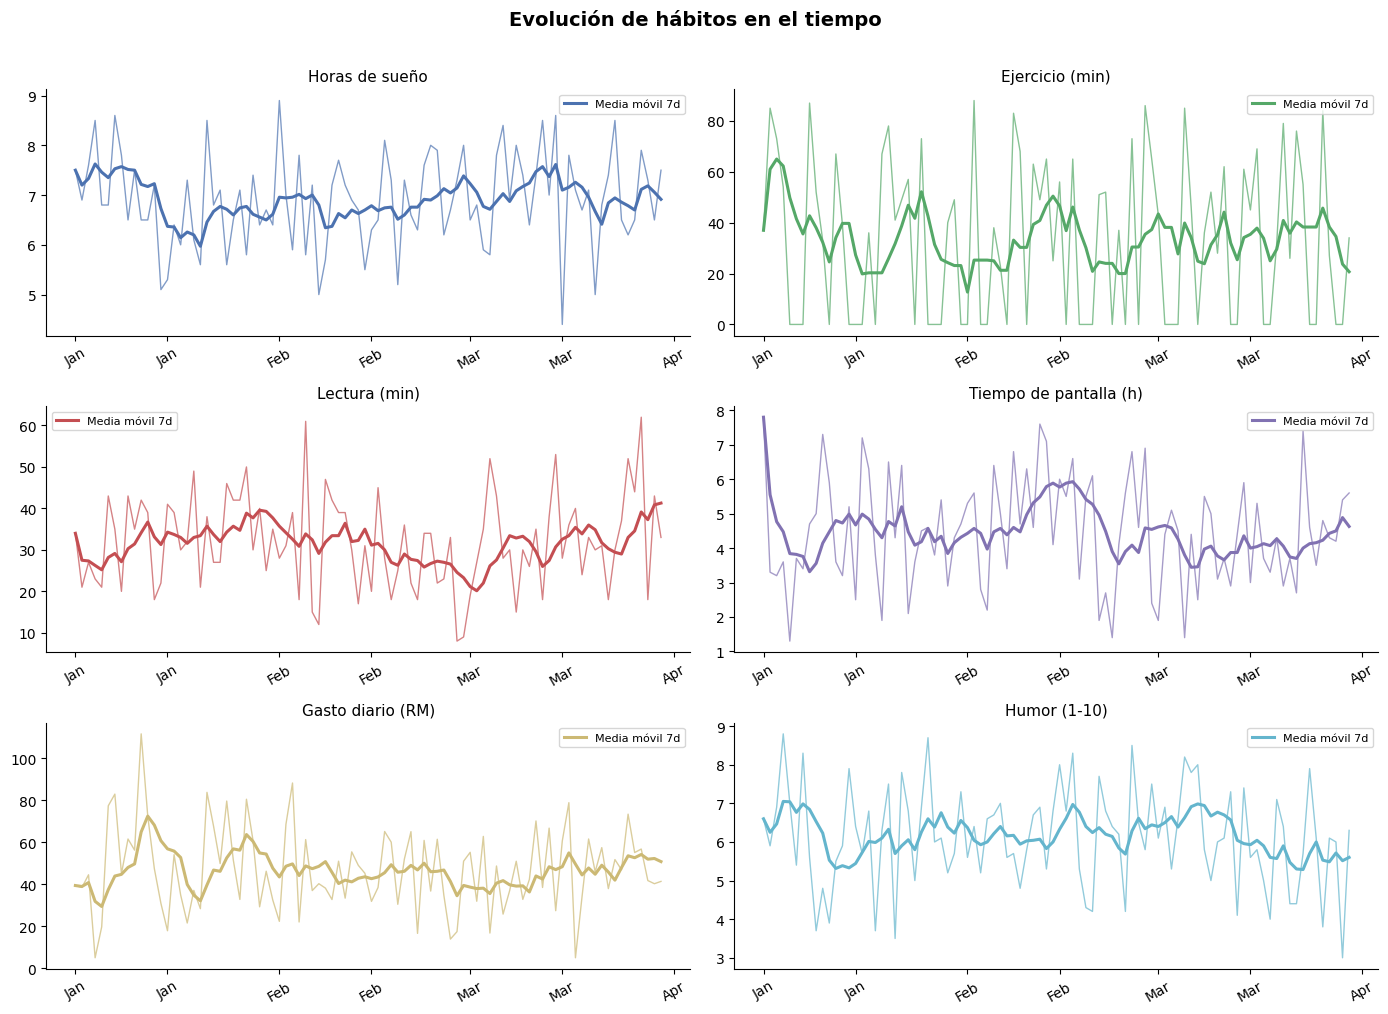

💾 Gráfico guardado: grafico_evolucion_temporal.png


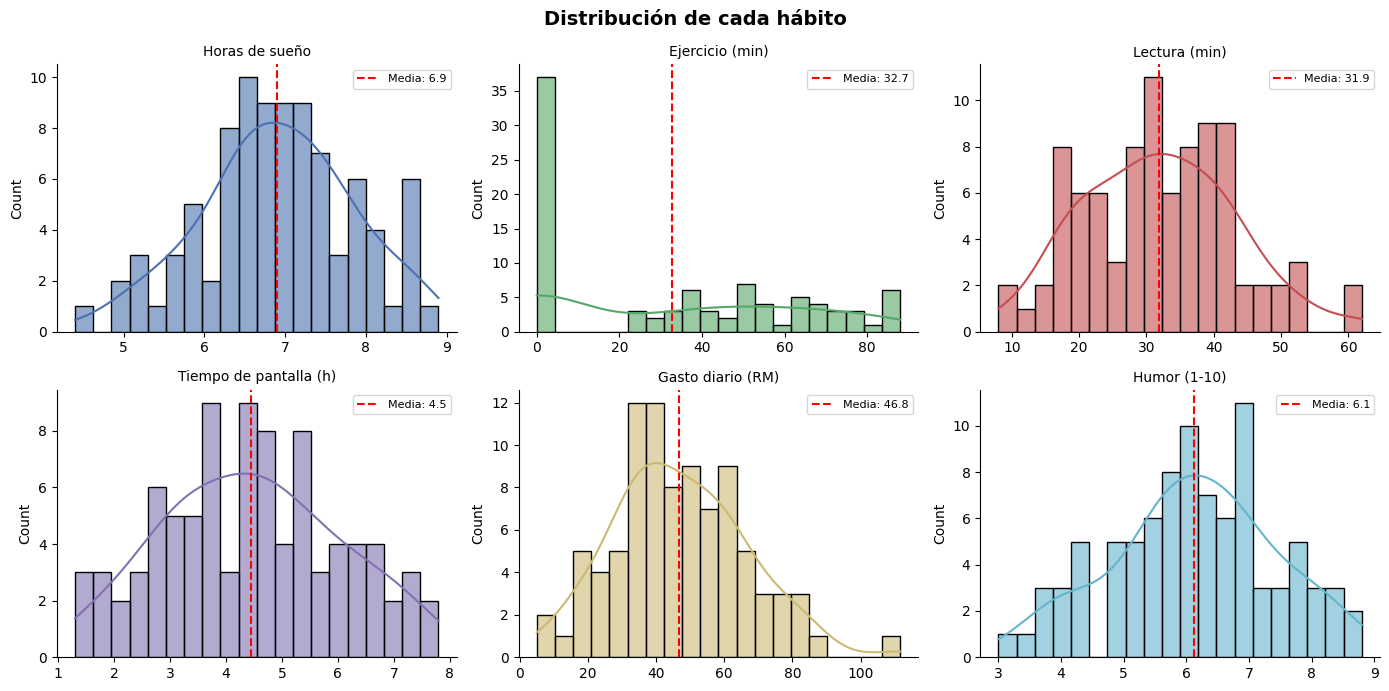

💾 Gráfico guardado: grafico_distribuciones.png


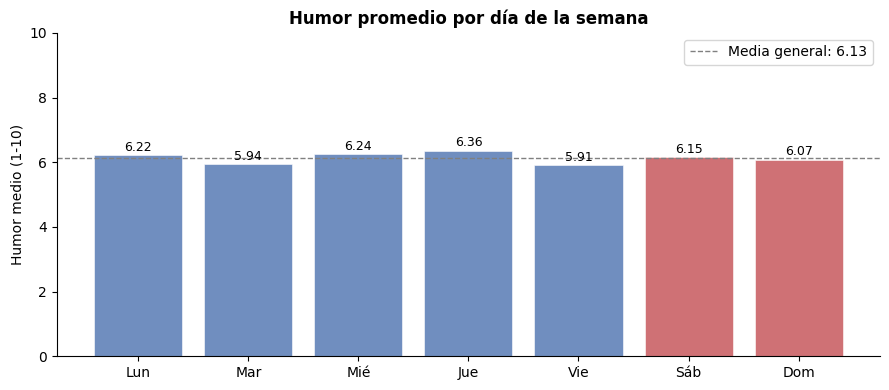

💾 Gráfico guardado: grafico_humor_semana.png


In [ ]:
# 1. Evolución temporal de todos los hábitos
# Un gráfico de líneas con múltiples subplots (subgráficos).
# Cada subplot muestra una variable en el tiempo.
# fig, axes = plt.subplots(filas, columnas) crea una cuadrícula de gráficos.

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Evolución de hábitos en el tiempo", fontsize=14, fontweight="bold", y=1.01)

variables = [
    ("sleep_h",      "Horas de sueño",      "#4C72B0"),
    ("workout_min",  "Ejercicio (min)",      "#55A868"),
    ("reading_min",  "Lectura (min)",        "#C44E52"),
    ("screen_h",     "Tiempo de pantalla (h)","#8172B2"),
    ("expense_rm",   "Gasto diario (RM)",    "#CCB974"),
    ("mood",         "Humor (1-10)",         "#64B5CD"),
]

for ax, (col, titulo, color) in zip(axes.flat, variables):
    # plot() dibuja la línea
    ax.plot(df.index, df[col], color=color, linewidth=1, alpha=0.7)
    # rolling(7).mean() calcula la media móvil de 7 días.
    # La media móvil suaviza el ruido y muestra la tendencia real.
    media_movil = df[col].rolling(window=7, min_periods=1).mean()
    ax.plot(df.index, media_movil, color=color, linewidth=2.2,
            label="Media móvil 7d")
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=8)
    # Formato del eje X para mostrar fechas legibles
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("grafico_evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_evolucion_temporal.png")


# 2. Distribuciones (histogramas)
# Un histograma divide los valores en "cubos" (bins) y cuenta
# cuántas veces cae cada valor en cada cubo.
# Permite ver si los datos siguen una distribución normal (campana de Gauss),
# si están sesgados hacia la derecha/izquierda, o si hay outliers.

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Distribución de cada hábito", fontsize=14, fontweight="bold")

for ax, (col, titulo, color) in zip(axes.flat, variables):
    # kde=True añade una curva de densidad sobre el histograma
    sns.histplot(df[col], ax=ax, color=color, kde=True, bins=20, alpha=0.6)
    # Línea vertical en la media
    ax.axvline(df[col].mean(), color="red", linestyle="--",
               linewidth=1.5, label=f"Media: {df[col].mean():.1f}")
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("grafico_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_distribuciones.png")


# 3. Humor promedio por día de la semana
fig, ax = plt.subplots(figsize=(9, 4))

humor_semana = df.groupby("weekday")["mood"].mean()
colores_dias = ["#4C72B0"] * 5 + ["#C44E52"] * 2  # azul entre semana, rojo finde
barras = ax.bar(DIAS, humor_semana.values, color=colores_dias, alpha=0.8,
                edgecolor="white", linewidth=0.5)

# Añadir etiquetas de valor encima de cada barra
for barra, valor in zip(barras, humor_semana.values):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.05,
            f"{valor:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(humor_semana.mean(), color="gray", linestyle="--",
           linewidth=1, label=f"Media general: {humor_semana.mean():.2f}")
ax.set_title("Humor promedio por día de la semana", fontsize=12, fontweight="bold")
ax.set_ylabel("Humor medio (1-10)")
ax.set_ylim(0, 10)
ax.legend()
plt.tight_layout()
plt.savefig("grafico_humor_semana.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_humor_semana.png")

##8. Análisis de correlaciones

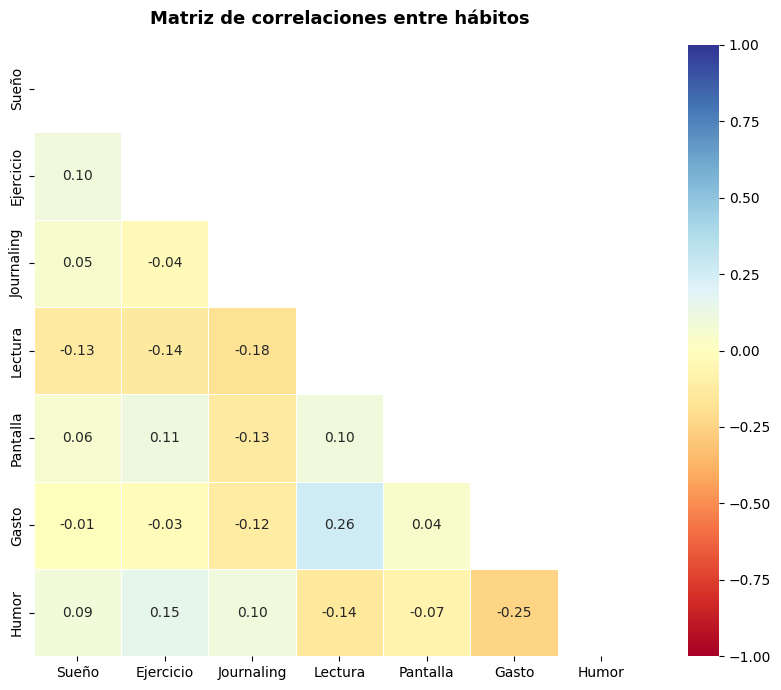

💾 Gráfico guardado: grafico_correlaciones_heatmap.png


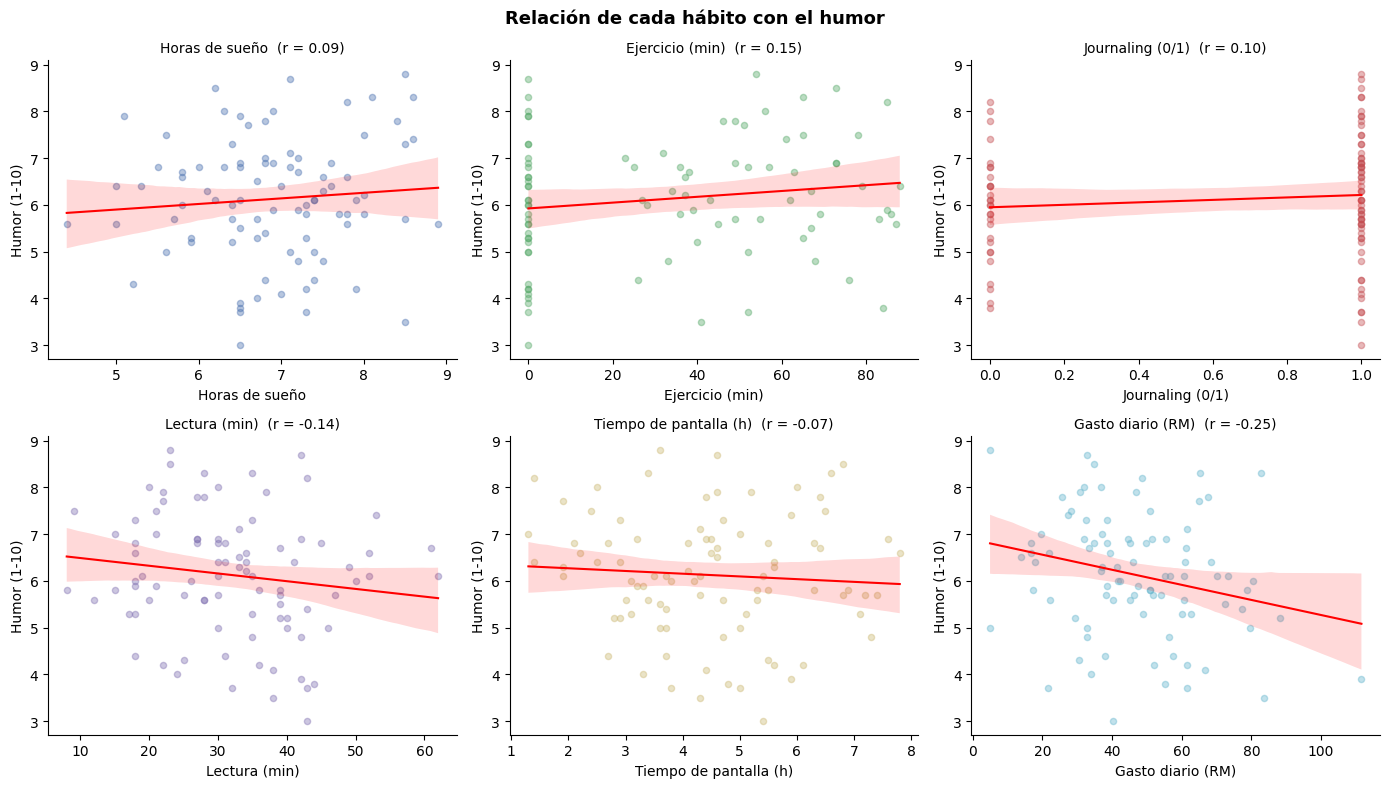

💾 Gráfico guardado: grafico_scatter_habitos_humor.png


In [ ]:
# ¿QUÉ ES UNA CORRELACIÓN?
# Mide si dos variables se mueven juntas o en sentido opuesto.
# El coeficiente de Pearson va de -1 a +1:
#   +1 → correlación perfecta positiva (si A sube, B sube igual)
#   0  → sin relación lineal
#   -1 → correlación perfecta negativa (si A sube, B baja igual)
#
# Regla práctica orientativa:
#   |r| < 0.3 → correlación débil
#   0.3 ≤ |r| < 0.6 → correlación moderada
#   |r| ≥ 0.6 → correlación fuerte
#
# Correlación NO implica causalidad. Que dormir más se
# correlacione con mejor humor no significa que sea la causa directa.

cols_corr = ["sleep_h", "workout_min", "journaling", "reading_min",
             "screen_h", "expense_rm", "mood"]

matriz_corr = df[cols_corr].corr()

# Heatmap (mapa de calor) de correlaciones
# Un heatmap colorea cada celda según el valor de correlación.
# Azul oscuro = correlación negativa fuerte
# Rojo/naranja = correlación positiva fuerte
# Blanco = sin correlación

fig, ax = plt.subplots(figsize=(9, 7))

etiquetas = ["Sueño", "Ejercicio", "Journaling", "Lectura",
             "Pantalla", "Gasto", "Humor"]

mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
# mask=mascara oculta el triángulo superior (es simétrico, no aporta info extra)
sns.heatmap(
    matriz_corr,
    mask=mascara,
    annot=True,          # muestra los valores numéricos en cada celda
    fmt=".2f",           # formato: 2 decimales
    cmap="RdYlBu",       # paleta Rojo-Amarillo-Azul
    center=0,            # el cero queda en el centro de la paleta (blanco)
    square=True,         # celdas cuadradas
    linewidths=0.5,
    xticklabels=etiquetas,
    yticklabels=etiquetas,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title("Matriz de correlaciones entre hábitos",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("grafico_correlaciones_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_correlaciones_heatmap.png")

# Scatter plots — Hábitos vs Humor
# El scatter plot (diagrama de dispersión) muestra la relación entre
# dos variables continuas. Cada punto es un día.
# Si los puntos forman una nube diagonal ascendente → correlación positiva.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Relación de cada hábito con el humor", fontsize=13,
             fontweight="bold")

habitos_vs_humor = [
    ("sleep_h",     "Horas de sueño",       "#4C72B0"),
    ("workout_min", "Ejercicio (min)",       "#55A868"),
    ("journaling",  "Journaling (0/1)",      "#C44E52"),
    ("reading_min", "Lectura (min)",         "#8172B2"),
    ("screen_h",    "Tiempo de pantalla (h)","#CCB974"),
    ("expense_rm",  "Gasto diario (RM)",     "#64B5CD"),
]

for ax, (col, etiqueta, color) in zip(axes.flat, habitos_vs_humor):
    # regplot añade automáticamente la línea de regresión lineal
    # y el intervalo de confianza (área sombreada)
    sns.regplot(data=df, x=col, y="mood", ax=ax,
                scatter_kws={"alpha": 0.4, "s": 20, "color": color},
                line_kws={"color": "red", "linewidth": 1.5})
    r = df[col].corr(df["mood"])  # coeficiente de correlación
    ax.set_title(f"{etiqueta}  (r = {r:.2f})", fontsize=10)
    ax.set_ylabel("Humor (1-10)")
    ax.set_xlabel(etiqueta)

plt.tight_layout()
plt.savefig("grafico_scatter_habitos_humor.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_scatter_habitos_humor.png")

##9. Análisis avanzado: Media móvil y tendencias

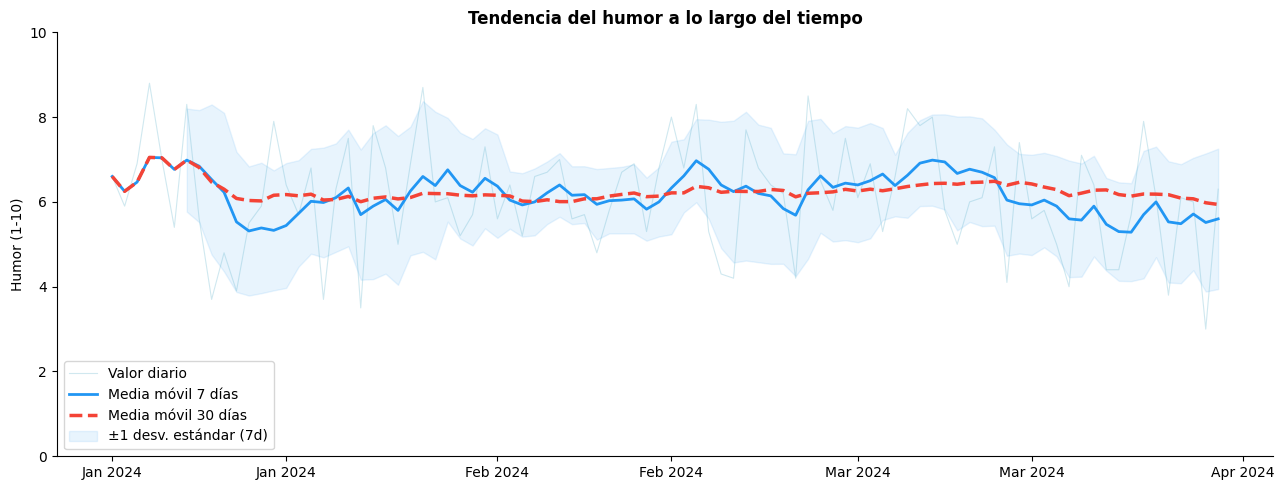

💾 Gráfico guardado: grafico_tendencia_humor.png


In [ ]:
# ¿QUÉ ES UNA MEDIA MÓVIL?
# Imagina que quieres saber la "tendencia" del humor de alguien
# sin que los días malos sueltos distorsionen la imagen.
# La media móvil calcula, para cada día,
# el promedio de los últimos 7 días.
# Es muy usada en finanzas (precios de acciones) y en series temporales.

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df.index, df["mood"],
        color="#64B5CD", alpha=0.3, linewidth=0.8, label="Valor diario")
ax.plot(df.index, df["mood"].rolling(7, min_periods=1).mean(),
        color="#2196F3", linewidth=2, label="Media móvil 7 días")
ax.plot(df.index, df["mood"].rolling(30, min_periods=1).mean(),
        color="#F44336", linewidth=2.5, linestyle="--", label="Media móvil 30 días")

ax.fill_between(df.index,
                df["mood"].rolling(7, min_periods=1).mean() - df["mood"].rolling(7).std(),
                df["mood"].rolling(7, min_periods=1).mean() + df["mood"].rolling(7).std(),
                alpha=0.1, color="#2196F3", label="±1 desv. estándar (7d)")

ax.set_title("Tendencia del humor a lo largo del tiempo", fontsize=12,
             fontweight="bold")
ax.set_ylabel("Humor (1-10)")
ax.set_ylim(0, 10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
plt.tight_layout()
plt.savefig("grafico_tendencia_humor.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado: grafico_tendencia_humor.png")

##10. Conclusiones

In [ ]:
# Los "insights" son las conclusiones accionables que extraemos del análisis.
# En una entrevista técnica, esta parte es igual de importante que el código.
# Demuestra que sabes interpretar los datos, no solo procesarlos.

print("=" * 55)
print("Resumen de insights")
print("=" * 55)

# Correlaciones con el humor
corr_mood = matriz_corr["mood"].drop("mood").sort_values(ascending=False)

print("\n📊 CORRELACIONES CON EL HUMOR (de mayor a menor):\n")
for hab, r in corr_mood.items():
    signo = "↑" if r > 0 else "↓"
    fuerza = "fuerte" if abs(r) >= 0.5 else "moderada" if abs(r) >= 0.3 else "débil"
    print(f"  {signo} {hab:15s}  r = {r:+.3f}  ({fuerza})")

# Mejor y peor día de la semana
humor_semana = df.groupby("weekday")["mood"].mean()
mejor_dia = DIAS[humor_semana.idxmax()]
peor_dia  = DIAS[humor_semana.idxmin()]
print(f"\n📅 Mejor día de la semana en humor: {mejor_dia} ({humor_semana.max():.2f})")
print(f"   Peor  día de la semana en humor: {peor_dia}  ({humor_semana.min():.2f})")

# Diferencia de humor en días con/sin ejercicio
humor_con_ej    = df.loc[df["workout_min"] > 0, "mood"].mean()
humor_sin_ej    = df.loc[df["workout_min"] == 0, "mood"].mean()
print(f"\n🏃 Humor medio con ejercicio:    {humor_con_ej:.2f}")
print(f"   Humor medio sin ejercicio:    {humor_sin_ej:.2f}")
print(f"   Diferencia:                  {humor_con_ej - humor_sin_ej:+.2f} puntos")

# Diferencia de humor con/sin journaling
humor_con_jour  = df.loc[df["journaling"] == 1, "mood"].mean()
humor_sin_jour  = df.loc[df["journaling"] == 0, "mood"].mean()
print(f"\n📓 Humor medio con journaling:   {humor_con_jour:.2f}")
print(f"   Humor medio sin journaling:   {humor_sin_jour:.2f}")
print(f"   Diferencia:                  {humor_con_jour - humor_sin_jour:+.2f} puntos")

print("\n" + "=" * 55)
print("Conclusiones (basadas en los datos)")
print("=" * 55)
if corr_mood["sleep_h"] > 0.01:
    print("  ✅ Dormir más horas se asocia con mejor humor.")
if corr_mood["workout_min"] > 0.01:
    print("  ✅ Los días con ejercicio muestran mayor puntuación de humor.")
if corr_mood["screen_h"] < -0.01:
    print("  ✅ El tiempo de pantalla se asocia con peor humor.")
print("\n  ⚠️  Recuerda: correlación ≠ causalidad.")
print("    Para establecer causalidad se necesitan experimentos controlados.")
print("=" * 55)

Resumen de insights

📊 CORRELACIONES CON EL HUMOR (de mayor a menor):

  ↑ workout_min      r = +0.148  (débil)
  ↑ journaling       r = +0.095  (débil)
  ↑ sleep_h          r = +0.086  (débil)
  ↓ screen_h         r = -0.071  (débil)
  ↓ reading_min      r = -0.142  (débil)
  ↓ expense_rm       r = -0.245  (débil)

📅 Mejor día de la semana en humor: Jue (6.36)
   Peor  día de la semana en humor: Vie  (5.91)

🏃 Humor medio con ejercicio:    6.29
   Humor medio sin ejercicio:    5.89
   Diferencia:                  +0.39 puntos

📓 Humor medio con journaling:   6.21
   Humor medio sin journaling:   5.95
   Diferencia:                  +0.26 puntos

Conclusiones (basadas en los datos)
  ✅ Dormir más horas se asocia con mejor humor.
  ✅ Los días con ejercicio muestran mayor puntuación de humor.
  ✅ El tiempo de pantalla se asocia con peor humor.

  ⚠️  Recuerda: correlación ≠ causalidad.
    Para establecer causalidad se necesitan experimentos controlados.
